## Research Question
Has there been a discursive shift in EU-funded project justifications from climate-oriented narratives to security- and resilience-oriented narratives?

Research plan:
* Inspect keyword frequency trends over the years (e.g., “climate”, “sustainability” vs. “security”, “resilience”, “strategic autonomy”)
* Topic modeling (BERTopic) to identify thematic clusters per year. Then compare thematic clusters over the years.
* Combining bag-of-words frequency analysis with sentence embedding-based topic modelling via BERTopic. 

To obtain results, I use the project's keywords, titles and descriptions (columns "metadata_title", "metadata_freeKeywords" and "metadata_objective". The data is obtained with the SEDIA-API-FETCHER.)

In [ ]:
import numpy as np
import pandas as pd
import json
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('wordnet')
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")



[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
with open("data/corpus.json", encoding="utf-8") as file:
    corpus_records = json.load(file)

# Keep project metadata in a DataFrame and the corresponding texts in a list.
# Both retain the same row order, which is required by the yearly analyses below.
data = pd.DataFrame(corpus_records)
corpus = data["_combined_text"].fillna("").astype(str).tolist()

print(f"Loaded {len(corpus):,} project texts")

Loaded 58,780 project texts


## Bag of Words

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text.lower())
    return " ".join(
        lemmatizer.lemmatize(token) 
        for token in tokens
        if token.isalpha()
    )

# Apply before fitting the vectorizers
lemmatized_corpus = [lemmatize_text(doc) for doc in corpus]

In [ ]:
#  1. BAG-OF-WORDS (word frequency counts) 
count_vec = CountVectorizer(
    min_df=2,               # ignore terms that appear in fewer than 2 docs
    max_features=500,       # keep only the top 500 terms
)

bow_matrix = count_vec.fit_transform(lemmatized_corpus)
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=count_vec.get_feature_names_out()
)

# Overall word frequencies across the whole lemmatized corpus
word_freq = bow_df.sum().sort_values(ascending=False)


In [ ]:
print(word_freq.head(100))

technology    43022
cell          32417
energy        31131
process       29782
aim           29121
              ...  
property      11387
large         11306
state         11291
industrial    11282
building      11221
Length: 100, dtype: int64


#### Frequency trends by project start year

Raw word counts cannot be compared directly across years because the number of projects and the amount of text differ. Therefore, the graphs below report occurrences per 10,000 words. The analysis uses project start year because it best represents when a project's justification entered the Horizon 2020 portfolio.

The term lists operationalise the two narratives in the research question. They should be treated as an explicit, reproducible dictionary rather than as a complete definition of either discourse. Years with fewer than 100 projects are excluded from the plots because their frequencies are unstable.

In [ ]:
# Extract a year from each project's start date.
data["start_year"] = pd.to_datetime(
    data["startdate"], errors="coerce", utc=True
).dt.year

# Dictionary-based operationalisation of the narratives in the research question.
# These forms match the lemmatised corpus produced above.
NARRATIVE_TERMS = {
    "Climate-oriented": [
        "climate", "climate change", "sustainability", "sustainable",
        "environment", "environmental", "renewable", "decarbonisation",
        "decarbonization", "green transition", "climate justice", "global warming",
        "carbon footprint", "carbon neutrality", "carbon neutral"
    ],
    "Security/resilience-oriented": [
        "security", "resilience", "resilient", "defence", "defense",
        "strategic autonomy", "autonomy", "sovereignty", "energy security",
        "preparedness", "vulnerability", "threat", "vulnerable", "self-sufficiency",
        "self-sufficient", "self-reliance", "self-reliant", "supply chain",
        "critical infrastructure", "securitize", "securitization", "geopolitical", "geostrategic"
    ],
}

term_to_narrative = {
    term: narrative
    for narrative, terms in NARRATIVE_TERMS.items()
    for term in terms
}

# Use a dedicated vectorizer so theoretically relevant terms are not removed by
# the max_features=500 setting used for the exploratory word-frequency table.
trend_vectorizer = CountVectorizer(
    vocabulary=list(term_to_narrative),
    ngram_range=(1, 2),
)
trend_matrix = trend_vectorizer.fit_transform(lemmatized_corpus)

term_counts = pd.DataFrame(
    trend_matrix.toarray(),
    columns=trend_vectorizer.get_feature_names_out(),
    index=data.index,
)

# Denominator used to compare years with different amounts of text.
data["token_count"] = [len(document.split()) for document in lemmatized_corpus]
term_counts["start_year"] = data["start_year"]
term_counts["token_count"] = data["token_count"]

In [ ]:
# Aggregate term counts and denominators by year.
terms = list(term_to_narrative)
annual_counts = term_counts.groupby("start_year")[terms].sum()
annual_tokens = term_counts.groupby("start_year")["token_count"].sum()
annual_projects = data.groupby("start_year").size()

# Occurrences per 10,000 words.
annual_frequency = annual_counts.div(annual_tokens, axis=0) * 10_000

# Avoid drawing conclusions from years represented by only a handful of projects.
MIN_PROJECTS_PER_YEAR = 100
included_years = annual_projects[annual_projects >= MIN_PROJECTS_PER_YEAR].index
annual_frequency = annual_frequency.loc[included_years]

year_summary = pd.DataFrame({
    "projects": annual_projects.loc[included_years],
    "analysed_words": annual_tokens.loc[included_years],
})
display(year_summary)

,projects,analysed_words
start_year,,
2014,882,145167
2015,4849,821566
2016,5142,874624
2017,4810,825552
2018,5324,913844
2019,5493,944448
2020,4588,796281
2021,3715,643850
2022,5149,881236


,term,rho,p_value,slope
2,resilient,0.969,0.000,0.285
1,resilience,0.960,0.000,0.579
5,strategic autonomy,0.883,0.000,0.038
8,preparedness,0.851,0.000,0.079
6,autonomy,0.824,0.000,0.077
7,sovereignty,0.820,0.000,0.079
4,defense,0.697,0.006,0.040
3,defence,0.077,0.794,0.000
0,security,-0.899,0.000,-0.356


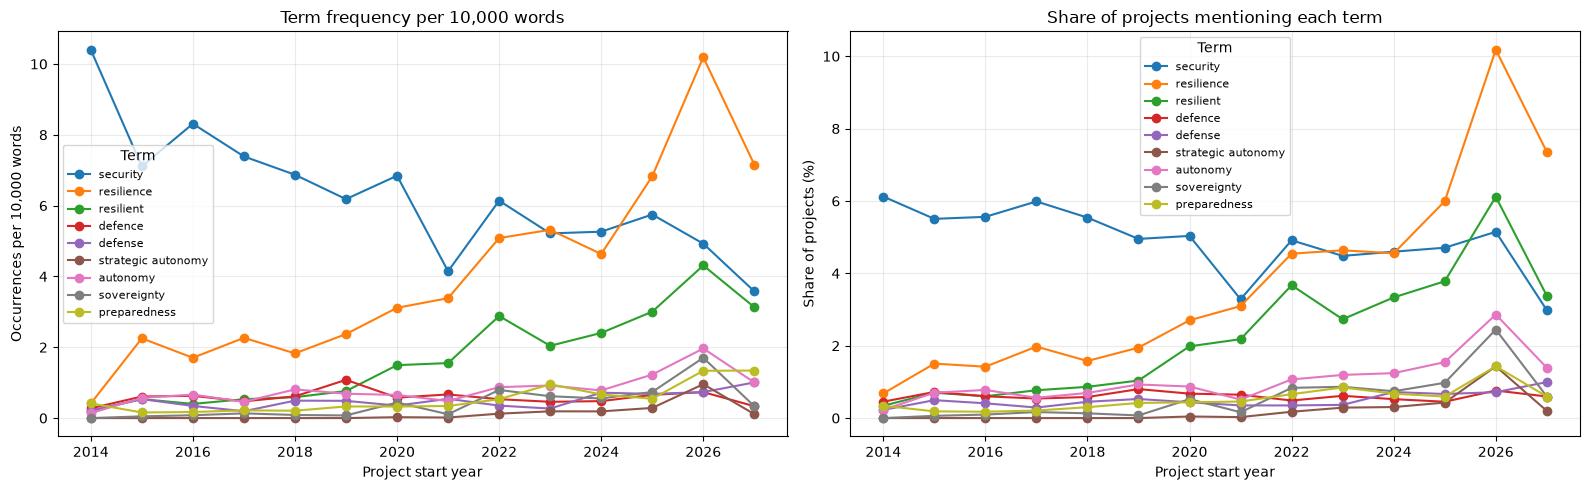

,security,resilience,resilient,defence,defense,strategic autonomy,autonomy,sovereignty,preparedness
start_year,,,,,,,,,
2014,10.40,0.41,0.21,0.28,0.21,0.00,0.14,0.00,0.41
2015,7.11,2.25,0.54,0.61,0.54,0.00,0.57,0.05,0.16
2016,8.31,1.70,0.40,0.63,0.34,0.00,0.66,0.08,0.17
2017,7.39,2.27,0.53,0.47,0.19,0.00,0.46,0.13,0.22
2018,6.87,1.83,0.59,0.61,0.49,0.00,0.81,0.09,0.21
2019,6.18,2.37,0.76,1.08,0.49,0.00,0.69,0.07,0.33
2020,6.84,3.11,1.49,0.58,0.35,0.03,0.65,0.44,0.33
2021,4.15,3.39,1.55,0.67,0.54,0.02,0.48,0.11,0.34
2022,6.14,5.08,2.88,0.53,0.35,0.12,0.87,0.79,0.53


,security,resilience,resilient,defence,defense,strategic autonomy,autonomy,sovereignty,preparedness
start_year,,,,,,,,,
2014,6.12,0.68,0.34,0.45,0.23,0.00,0.23,0.00,0.34
2015,5.51,1.51,0.70,0.72,0.49,0.00,0.70,0.06,0.19
2016,5.56,1.42,0.60,0.60,0.41,0.00,0.78,0.10,0.18
2017,5.99,1.98,0.77,0.54,0.29,0.00,0.56,0.17,0.21
2018,5.54,1.58,0.86,0.58,0.45,0.00,0.69,0.13,0.30
2019,4.95,1.95,1.04,0.80,0.53,0.00,0.93,0.07,0.42
2020,5.03,2.70,1.98,0.68,0.44,0.04,0.87,0.52,0.44
2021,3.28,3.10,2.18,0.65,0.35,0.03,0.51,0.16,0.46
2022,4.91,4.54,3.67,0.49,0.35,0.17,1.07,0.84,0.66


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=False)
# Supplementary view: heatmap of terms that actually occur
heatmap_data = term_frequency[terms].copy()
# Keep only columns (terms) that have at least one non-zero value across years
heatmap_data = heatmap_data.loc[:, (heatmap_data.sum(axis=0) > 0)]
# Order terms by mean frequency so the strongest terms appear first
term_order = heatmap_data.mean().sort_values(ascending=False).index
heatmap_data = heatmap_data[term_order]
# Draw heatmap: rows = terms, cols = years (so transpose the DataFrame)
im = axes[1].imshow(heatmap_data.T.values, aspect="auto", cmap="viridis")
axes[1].set_title("Narrative terms with at least one occurrence")
# x-axis: project start years (columns of the original heatmap_data)
axes[1].set_xticks(range(len(heatmap_data.index)))
axes[1].set_xticklabels(heatmap_data.index, rotation=45, ha="right")
# y-axis: narrative terms (rows after transpose)
axes[1].set_yticks(range(len(heatmap_data.columns)))
axes[1].set_yticklabels(heatmap_data.columns)
axes[1].set_xlabel("Project start year")
axes[1].set_ylabel("Narrative term")
fig.colorbar(im, ax=axes[1], pad=0.02)


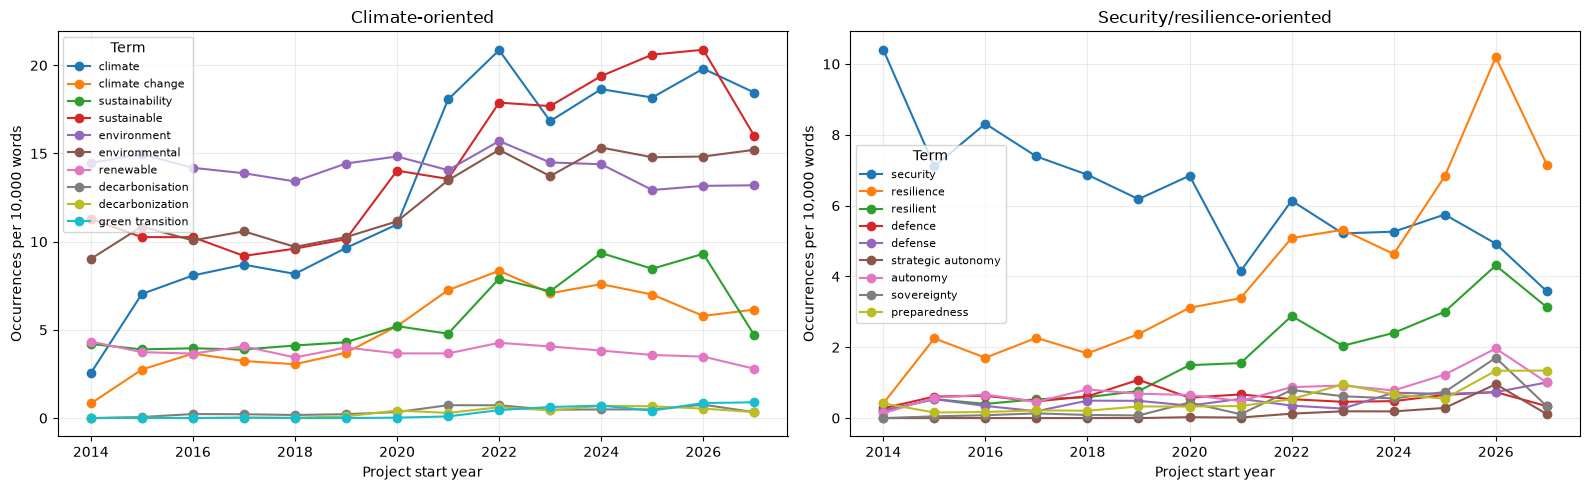

In [ ]:
# Inspect a compact set of core terms for each narrative so the plot stays readable.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, (narrative, narrative_terms) in zip(axes, NARRATIVE_TERMS.items()):
    top_terms = (
        term_frequency[narrative_terms]
        .mean()
        .sort_values(ascending=False)
        .head(3)
        .index.tolist()
    )
    term_frequency[top_terms].plot(ax=ax, marker="o")
    ax.set_title(f"{narrative} — core terms")
    ax.set_xlabel("Project start year")
    ax.set_ylabel("Occurrences per 10,000 words")
    ax.grid(alpha=0.25)
    ax.legend(title="Term", fontsize=8)

plt.tight_layout()
plt.show()


#### Robustness check: share of projects mentioning each narrative

Repeated use of a word in a small number of projects could dominate token frequency. The following measure instead counts each project at most once per narrative and reports the percentage of projects that mention at least one dictionary term.

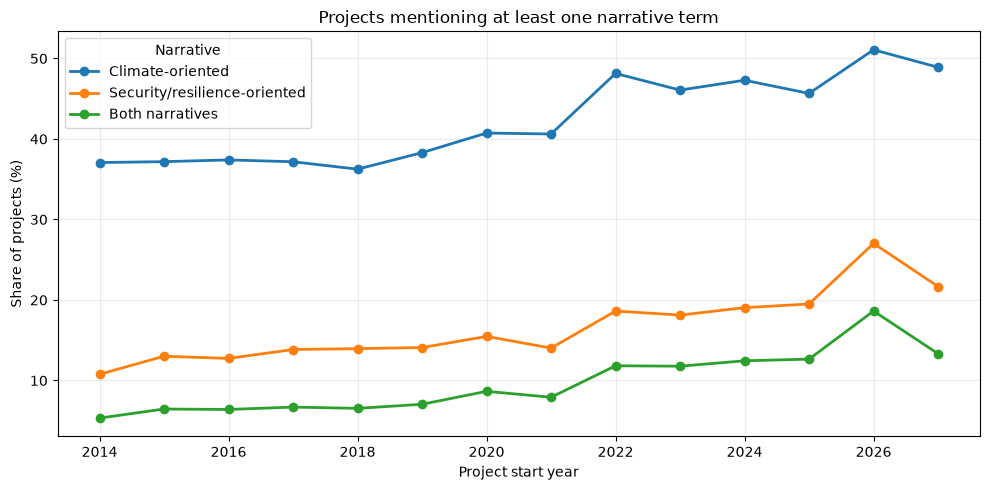

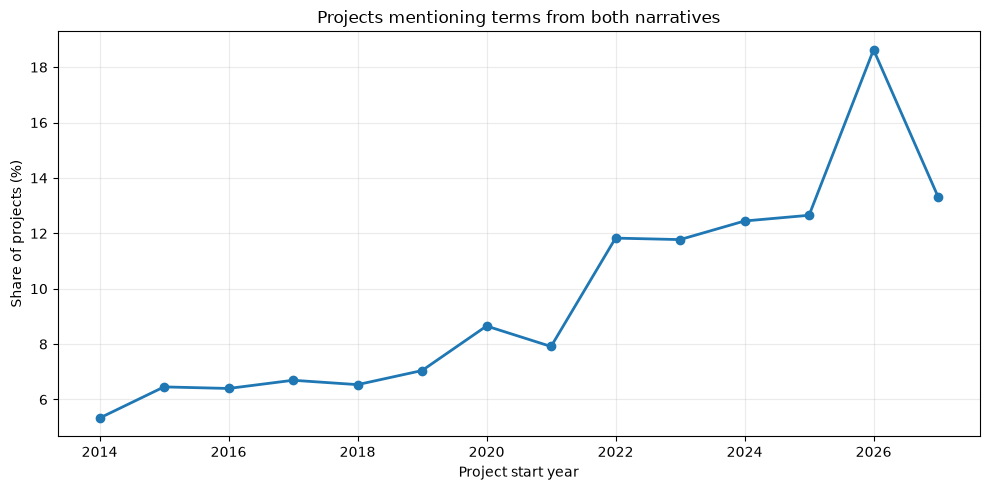

,Climate-oriented,Security/resilience-oriented,Both narratives
start_year,,,
2014,37.07,10.77,5.33
2015,37.18,13.01,6.45
2016,37.40,12.74,6.40
2017,37.17,13.85,6.69
2018,36.25,13.96,6.54
2019,38.30,14.09,7.05
2020,40.74,15.48,8.65
2021,40.62,14.02,7.91
2022,48.15,18.62,11.83


In [ ]:
project_mentions = pd.DataFrame(index=data.index)
project_mentions["start_year"] = data["start_year"]

for narrative, terms in NARRATIVE_TERMS.items():
    project_mentions[narrative] = term_counts[terms].sum(axis=1).gt(0)

project_mentions["Both narratives"] = project_mentions[list(NARRATIVE_TERMS)].all(axis=1)

annual_project_share = (
    project_mentions.groupby("start_year")[list(NARRATIVE_TERMS) + ["Both narratives"]]
    .mean()
    .mul(100)
    .loc[included_years]
)

ax = annual_project_share.plot(figsize=(10, 5), marker="o", linewidth=2)
ax.set(
    title="Projects mentioning at least one narrative term",
    xlabel="Project start year",
    ylabel="Share of projects (%)",
)
ax.grid(alpha=0.25)
ax.legend(title="Narrative")
plt.tight_layout()
plt.show()

ax = (
    project_mentions.groupby("start_year")["Both narratives"]
    .mean()
    .mul(100)
    .loc[included_years]
    .plot(figsize=(10, 5), marker="o", linewidth=2)
)
ax.set(
    title="Projects mentioning terms from both narratives",
    xlabel="Project start year",
    ylabel="Share of projects (%)",
)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(annual_project_share.round(2))
